In [2]:
import numpy as np
import xarray as xr
import pandas as pd

import glob as glob
import matplotlib.pyplot as mp

In [24]:
from dask.distributed import Client
from ncar_jobqueue import NCARCluster

In [25]:
cluster = NCARCluster(project='P93300642',interface='ext', job_extra_directives=[])
cluster
cluster.scale(jobs=32)
client = Client(cluster)
client

/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/dask_jobqueue/core.py:266: FutureWarning: job_extra has been renamed to job_extra_directives. You are still using it (even if only set to []; please also check config files). If you did not set job_extra_directives yet, job_extra will be respected for now, but it will be removed in a future release. If you already set job_extra_directives, job_extra is ignored and you can remove it.
  warnings.warn(warn, FutureWarning)
/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/dask_jobqueue/core.py:285: FutureWarning: env_extra has been renamed to job_script_prologue. You are still using it (even if only set to []; please also check config files). If you did not set job_script_prologue yet, env_extra will be respected for now, but it will be removed in a future release. If you already set job_script_prologue, env_extra is ignored and you can remove it.
  warnings.warn(warn, Fu

Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/35669/status,
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/35669/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.100:42969,Workers: 0
Dashboard: https://jupyterhub.hpc.ucar.edu/stable/user/rneale/proxy/35669/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [44]:
# Read in daily data

dir0 = '/glade/derecho/scratch/hannay/archive/'
dir_fig = '/glade/u/home/rneale/python/python-figs/CAM7_CESM3_dev/'

#case = 'b.e23_alpha17f.BLTHIST.ne30_t232.092'
#case = 'b.e23_alpha17f.BLT1850.ne30_g17.POP.096'
#case = 'b.e23_alpha16g.BLT1850.ne30_t232.082b'
case = 'b.e23_alpha17f.BLT1850.ne30_t232.093'
#case = 'f.cam6_3_160.FMTHIST_ne30.001'
var_name = 'PRECT'

#lonr_w = 200.
#lonr_e = 270.

lonr_w = 220.
lonr_e = 240.



lon_str = str(int(lonr_w))+'E-'+str(int(lonr_e))+'E'
lon_str

'220E-240E'

In [45]:
ovoffset = 0.


if var_name == 'PRECT':
    clevels = [0,1,2,3,4,5,6,8,10,12,16,18,20]
    cmap = 'terrain_r'
    vscale = 86400.*1000. ; voffset = 0.
    ovscale = 1000.*24.
    ovar_name = 'tp'
    ofile_in = 'precip_era5_dclim_noleap_1x1.nc'

if var_name == 'U850':
    clevels = [-10,-8,-6,-5,-4,-3,-2,-1,0,1,2,3,4,5,6,8,10]
    cmap = 'PiYG_r'
    vscale = 1.
    ovscale = 1.
    ovar_name = 'u'
    ofile_in = 'u850_era5_dclim_noleap_1x1.nc'

if var_name == 'V850':
    clevels = [-5,-4,-3,-2.5,-2,-1.5,-1,-0.5,0,0.5,1,1.5,2,2.5,3,4,5]
    cmap = 'PiYG_r'
    vscale = 1.
    ovscale = 1.
    ovar_name = 'v'
    ofile_in = 'v850_era5_dclim_noleap_1x1.nc'

if var_name == 'LHFLX':
    clevels = [180,190,200,210,220,230,240,250,260,270,280,290,300,310]
    cmap = 'RdYlBu_r'
    vscale = 24.
    ovscale = 1.
    ovar_name = 'slhf'
    ofile_in = 'lhflx_era5_dclim_noleap_1x1.nc'

if var_name == 'TS':
#    clevels = [290,292,294,296,297,298,298.5,299,299.5,300,300.5,301,301.5,302]
    clevels = [24,25,26,27,27.25,27.5,27.75,28,28.25,28.5,28.75,29,29.25,29.5,29.75,30]
    cmap = 'jet'
    vscale = 1. ; voffset = -273.16
   
## ERA5
#    ovar_name = 'ts'
#    ofile_in = 'ts_era5_dclim_noleap_1x1.nc'
    ovscale = 1. ; ovoffset = -273.16

## NOAA
    ovar_name = 'SST_cpl'
    ofile_in = 'sst_reynolds_daily_0.9x1.25_yrs1982-2018_timeseries_c20190822.nc'
    ovscale = 1. ; ovoffset = 1


In [46]:
dir_in = dir0+case+'/atm/hist/'
files_stub = dir_in+case+'.cam.h2a.*nc' 
print(files_stub)

files_list = sorted(glob.glob(files_stub))
df_case = xr.open_mfdataset(files_list, engine="netcdf4",parallel=True,chunks={"time": 365})

/glade/derecho/scratch/hannay/archive/b.e23_alpha17f.BLT1850.ne30_t232.093/atm/hist/b.e23_alpha17f.BLT1850.ne30_t232.093.cam.h2a.*nc


In [47]:
df_case

<xarray.Dataset>
Dimensions:       (lat: 192, lon: 288, time: 8030, lev: 58, ilev: 59,
                   trop_cld_lev: 58, nbnd: 2)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.3 357.5 358.8
  * lev           (lev) float64 3.018 5.445 9.087 14.25 ... 983.2 991.2 997.5
  * ilev          (ilev) float64 2.055 3.98 6.909 11.27 ... 987.4 995.1 1e+03
  * trop_cld_lev  (trop_cld_lev) float64 3.018 5.445 9.087 ... 983.2 991.2 997.5
  * time          (time) object 0001-01-01 12:00:00 ... 0022-12-31 12:00:00
Dimensions without coordinates: nbnd
Data variables: (12/24)
    w             (time, lat) float64 dask.array<chunksize=(20, 192), meta=np.ndarray>
    hyam          (time, lev) float64 dask.array<chunksize=(20, 58), meta=np.ndarray>
    hybm          (time, lev) float64 dask.array<chunksize=(20, 58), meta=np.ndarray>
    hyai          (time, ilev) float64 dask.array<chunksize=(20, 59), meta=np.ndarray>
    hybi          (time, ilev) float64 dask.array<chunksize=(20, 59), meta=np.ndarray>
    date          (time) int32 dask.array<chunksize=(20,), meta=np.ndarray>
    ...            ...
    PSL           (time, lat, lon) float32 dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    U200          (time, lat, lon) float32 dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    U850          (time, lat, lon) float32 dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    V200          (time, lat, lon) float32 dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    V850          (time, lat, lon) float32 dask.array<chunksize=(20, 192, 288), meta=np.ndarray>
    OMEGA         (time, lev, lat, lon) float32 dask.array<chunksize=(20, 58, 192, 288), meta=np.ndarray>
Attributes:
    interp_type:       bilinear
    interp_outputgri:  equally spaced with poles
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e23_alpha17f.BLT1850.ne30_t232.093
    logname:           hannay
    host:              dec1661
    initial_file:      /glade/campaign/cesm/cesmdata/inputdata/atm/cam/inic/s...
    topography_file:   /glade/campaign/cesm/cesmdata/inputdata/atm/cam/topo/s...
    model_doi_url:     not_set
    time_period_freq:  day_1

In [48]:
var_in = df_case[var_name]

# Ensure the time coordinate is in DatetimeIndex
#var_in['time'] = pd.to_datetime(var_in['time'].values)

# Group by day of the year
doy_grouped = var_in.groupby('time.dayofyear')

# Calculate the mean for each day of the year to get the climatology
doy_climatology = doy_grouped.mean(dim='time')

# Reconstruct the annual cycle (optional)
annual_cycle = doy_climatology.sel(dayofyear=var_in['time'].dt.dayofyear)

# Select the longitudinal range (200 to 270 degrees east)
selected_lon = doy_climatology.sel(lon=slice(lonr_w, lonr_e))
print(selected_lon.max)
# Compute the zonal average
zonal_average = selected_lon.mean(dim='lon')
zonal_average = zonal_average*vscale+voffset

# Save the climatology to a new NetCDF file
#doy_climatology.to_netcdf('doy_annual_climatology.nc')


<bound method DataArrayAggregations.max of <xarray.DataArray 'PRECT' (dayofyear: 365, lat: 192, lon: 16)>
dask.array<getitem, shape=(365, 192, 16), dtype=float32, chunksize=(1, 192, 16), chunktype=numpy.ndarray>
Coordinates:
  * lat        (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon        (lon) float64 221.3 222.5 223.8 225.0 ... 236.3 237.5 238.8 240.0
  * dayofyear  (dayofyear) int64 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365
Attributes:
    units:         m/s
    long_name:     Total (convective and large-scale) precipitation rate (liq...
    cell_methods:  time: mean>


/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing with an out-of-order index is generating 22 times more chunks
  return self.array[key]


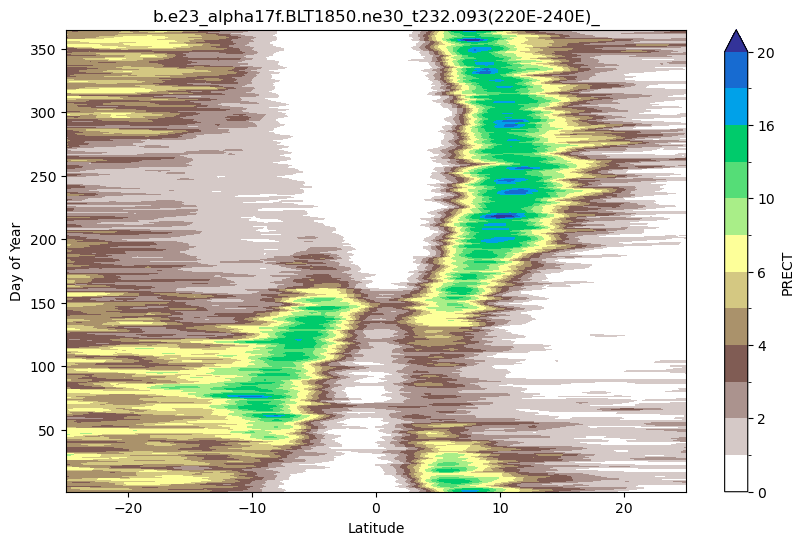

In [49]:
mp.figure(figsize=(10, 6))
zonal_average.plot.contourf(cmap=cmap, levels=clevels)
mp.title(case+' ('+lon_str+')')
mp.ylabel('Day of Year')
mp.xlabel('Latitude')
mp.xlim([-25.0, 25.0])
mp.savefig(dir_fig+case+'_'+var_name+'_epac'+lon_str+'_itcz.png', dpi=100, bbox_inches='tight')
mp.show()

In [52]:
## Obs.

ocase = 'ERA5'
odir = '/glade/derecho/scratch/rneale/ERA5/dmean/1deg/'

#ocase = 'NOAA'
#odir = '/glade/campaign/cesm/cesmdata/cseg/inputdata/atm/cam/sst/'


file_all = odir+ofile_in

print(file_all)
df_obs = xr.open_dataset(file_all, engine="netcdf4",decode_times = True)


/glade/derecho/scratch/rneale/ERA5/dmean/1deg/precip_era5_dclim_noleap_1x1.nc


In [53]:
# Compute the zonal average


ovar_in = df_obs[ovar_name]


# For NOAA need to calculate mean annaual cycle.
if ocase == 'NOAA':
    odoy_grouped = ovar_in.groupby('time.dayofyear')
    
    # Calculate the mean for each day of the year to get the climatology
    odoy_climatology = odoy_grouped.mean(dim='time')
    
    # Reconstruct the annual cycle (optional)
    oannual_cycle = odoy_climatology.sel(dayofyear=ovar_in['time'].dt.dayofyear)

else:

    odoy_climatology = ovar_in 
    
# Select the longitudinal range (200 to 270 degrees east)
oselected_lon = odoy_climatology.sel(lon=slice(lonr_w, lonr_e))
  
# Compute the zonal average
ozonal_average = oselected_lon.mean(dim='lon')
print(voffset,vscale)
ozonal_average.values
ozonal_average = ozonal_average*ovscale+ovoffset











# Save the climatology to a new NetCDF file
#doy_climatology.to_netcdf('odoy_annual_climatology.nc')

0.0 86400000.0


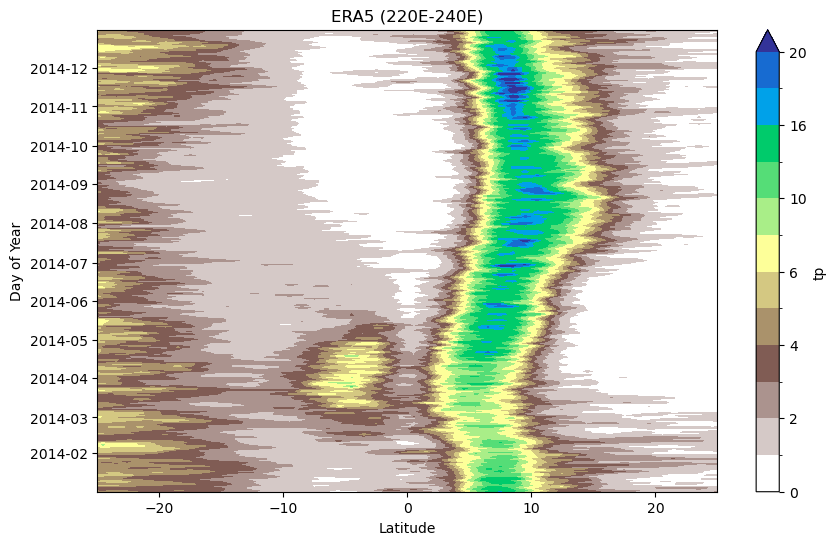

In [54]:
mp.figure(figsize=(10, 6))
ozonal_average.plot.contourf(cmap=cmap, levels=clevels)
mp.title('ERA5 ('+lon_str+')')
mp.ylabel('Day of Year')
mp.xlabel('Latitude')
mp.xlim([-25.0, 25.0])

mp.savefig(dir_fig+ocase+'_'+var_name+'_epac'+lon_str+'_itcz.png', dpi=100, bbox_inches='tight')
mp.show()

In [4]:
lcase = 'b.e21.BHISTcmip6.f09_g17.LE2-1001.001'
ldir0 = '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/'

ldir_in = ldir0+var_name+'/'
lfiles_stub = ldir_in+lcase+'.cam.h1.*.18*nc' 


lfiles_list = sorted(glob.glob(lfiles_stub))
print(lfiles_list)
df_lcase = xr.open_mfdataset(lfiles_list, engine="netcdf4",parallel=True,chunks={"time": 365})
df_lcase

['/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/TS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.TS.18500101-18591231.nc', '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/TS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.TS.18600101-18691231.nc', '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/TS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.TS.18700101-18791231.nc', '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/TS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.TS.18800101-18891231.nc', '/glade/campaign/cgd/cesm/CESM2-LE/atm/proc/tseries/day_1/TS/b.e21.BHISTcmip6.f09_g17.LE2-1001.001.cam.h1.TS.18900101-18991231.nc']


/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/xarray/core/dataset.py:275: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/xarray/core/dataset.py:275: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/xarray/core/dataset.py:275: UserWarning: The specified chunks separate the stored chunks along dimension "time" starting at index 365. This could degrade performance. Instead, consider rechunking after loading.
  warnings.warn(
/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/p

<xarray.Dataset>
Dimensions:       (lat: 192, lon: 288, time: 18250, lev: 32, ilev: 33, nbnd: 2)
Coordinates:
  * lat           (lat) float64 -90.0 -89.06 -88.12 -87.17 ... 88.12 89.06 90.0
  * lon           (lon) float64 0.0 1.25 2.5 3.75 ... 355.0 356.2 357.5 358.8
  * lev           (lev) float64 3.643 7.595 14.36 24.61 ... 957.5 976.3 992.6
  * ilev          (ilev) float64 2.255 5.032 10.16 18.56 ... 967.5 985.1 1e+03
  * time          (time) object 1850-01-01 00:00:00 ... 1899-12-31 00:00:00
Dimensions without coordinates: nbnd
Data variables: (12/26)
    gw            (time, lat) float64 dask.array<chunksize=(3650, 192), meta=np.ndarray>
    hyam          (time, lev) float64 dask.array<chunksize=(3650, 32), meta=np.ndarray>
    hybm          (time, lev) float64 dask.array<chunksize=(3650, 32), meta=np.ndarray>
    P0            (time) float64 1e+05 1e+05 1e+05 1e+05 ... 1e+05 1e+05 1e+05
    hyai          (time, ilev) float64 dask.array<chunksize=(3650, 33), meta=np.ndarray>
    hybi          (time, ilev) float64 dask.array<chunksize=(3650, 33), meta=np.ndarray>
    ...            ...
    n2ovmr        (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    f11vmr        (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    f12vmr        (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    sol_tsi       (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    nsteph        (time) float64 dask.array<chunksize=(365,), meta=np.ndarray>
    TS            (time, lat, lon) float32 dask.array<chunksize=(365, 192, 288), meta=np.ndarray>
Attributes:
    Conventions:       CF-1.0
    source:            CAM
    case:              b.e21.BHISTcmip6.f09_g17.LE2-1001.001
    logname:           sunseon
    host:              mom1
    initial_file:      b.e21.B1850.f09_g17.CMIP6-piControl.001.cam.i.1001-01-...
    topography_file:   /mnt/lustre/share/CESM/cesm_input/atm/cam/topo/fv_0.9x...
    model_doi_url:     https://doi.org/10.5065/D67H1H0V
    time_period_freq:  day_1

In [23]:
lvar_in = df_lcase[var_name]

# Ensure the time coordinate is in DatetimeIndex
#var_in['time'] = pd.to_datetime(var_in['time'].values)

# Group by day of the year
ldoy_grouped = lvar_in.groupby('time.dayofyear')

# Calculate the mean for each day of the year to get the climatology
ldoy_climatology = ldoy_grouped.mean(dim='time')

# Reconstruct the annual cycle (optional)
lannual_cycle = ldoy_climatology.sel(dayofyear=lvar_in['time'].dt.dayofyear)

# Select the longitudinal range (200 to 270 degrees east)
lselected_lon = ldoy_climatology.sel(lon=slice(lonr_w, lonr_e))

# Compute the zonal average
lzonal_average = lselected_lon.mean(dim='lon')
print(voffset,vscale)
lzonal_average.values
lzonal_average = lzonal_average*vscale+voffset
lzonal_average.values

/glade/work/rneale/python/miniconda3/envs/neale_monsoon/lib/python3.11/site-packages/xarray/core/indexing.py:1446: PerformanceWarning: Slicing with an out-of-order index is generating 50 times more chunks
  return self.array[key]


-273.16 1.0


KeyboardInterrupt: 

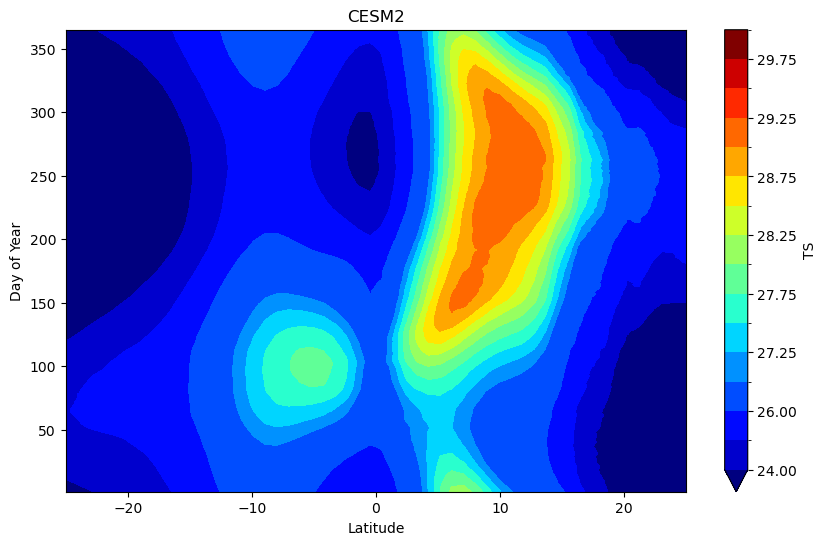

In [13]:
# Save the climatology to a new NetCDF file
#doy_climatology.to_netcdf('doy_annual_climatology.nc')

mp.figure(figsize=(10, 6))
lzonal_average.plot.contourf(cmap=cmap, levels=clevels)
mp.title('CESM2')
mp.ylabel('Day of Year')
mp.xlabel('Latitude')
mp.xlim([-25.0, 25.0])

mp.savefig(dir_fig+lcase+'_'+var_name+'_epac_itcz'+lon_str+'.png', dpi=100, bbox_inches='tight')
mp.show()
